In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
path = "/content/gdrive/MyDrive/Colab Notebooks/"
import sys; sys.path.append(path+'lib')
from variable_print import p,ps,pst

In [3]:
%%capture
!pip install gym[classic_control]

# REINFORCE Algorithm 구현 2

In [4]:
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.distributions import Categorical
import matplotlib.pyplot as plt
import time
plt.rcParams['figure.figsize'] = [5, 3.5]
plt.rcParams["font.size"] = "8"

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

## Environment : CartPole 생성

In [5]:
env = gym.make("CartPole-v1", render_mode="rgb_array")
print(gym.__version__)  #0.25.2
print("="*10)
print('State space: ', env.observation_space)
print('Action space: ', env.action_space)
print("="*10)
s_dim = env.observation_space.shape[0]
a_dim = env.action_space.n
print(f"State dimension: {s_dim}")
print(f"Action dimension: {a_dim}")

1.2.0
State space:  Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Action space:  Discrete(2)
State dimension: 4
Action dimension: 2


## Neural Network 만들기  

In [6]:
class PolicyNetwork(nn.Module):
    def __init__(self, state_size=4, action_size=2, hidden_size=30):
        super(PolicyNetwork, self).__init__()
        self.fc1 = nn.Linear(state_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, hidden_size)
        self.fc3 = nn.Linear(hidden_size, action_size)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # 행동 확률을 출력하기 위해 Softmax 적용
        action_probs = F.softmax(self.fc3(x), dim=-1)
        return action_probs

## REINFORCE Agent 만들기   
### Episode단위로 학습 하기


### Memory handling 준비
```python
# sample(st,at,rt,st+1,done)을 저장해주고 리턴을 계산
memory = EpisodicMemory(max_size=100, gamma=1.0)
```

### Trajectory를 받아서 저장, done을 만나면 return값을 계산해서 보관  

```python
class Trajectory:
    def __init__(self, gamma: float):
        self.states = list()
        ...
        self.dones = list()
    def push(self, state, action, reward, next_state, done):
        self.states.append(state)
        ...
        self.dones.append(done)
        if done: self.compute_return()

    def compute_return(self): # return 계산
        for r in rewards[::-1]:
            g = r + self.gamma * g
            ...
        self.returns = returns

    def get_samples(self):
        states = np.array(self.states)    # na.array() <- list()
        ...
        returns = np.array(self.returns)
        return states, actions,rewards,next_states, dones, returns
```         

In [7]:
"""## 메모리 관리 클래스 (Trajectory & EpisodicMemory)"""

class Trajectory:
    """한 에피소드의 궤적(Trajectory)을 저장하고 Return을 계산"""
    def __init__(self, gamma: float):
        self.gamma = gamma
        self.states = []
        self.actions = []
        self.rewards = []
        self.next_states = []
        self.dones = []
        self.returns = None
        self._discounted = False

    def push(self, state, action, reward, next_state, done):
        self.states.append(state)
        self.actions.append(action)
        self.rewards.append(reward)
        self.next_states.append(next_state)
        self.dones.append(done)

        if done and not self._discounted:
            self.compute_return()

    def compute_return(self):
        returns = []
        g = 0
        for r in reversed(self.rewards):
            g = r + self.gamma * g
            returns.insert(0, g)
        self.returns = returns
        self._discounted = True

    def get_samples(self):
        return (np.array(self.states), np.array(self.actions),
                np.array(self.rewards), np.array(self.next_states),
                np.array(self.dones), np.array(self.returns))


### Queue에 Trajectory단위로 push / pop

```python
# deque : 양쪽 방향에서 element 추가, 제거 가능 # queue : FIFO
from collections import deque
class EpisodicMemory:
    def __init__(self, max_size: int, gamma: float):
        ...
        self.trajectories = deque(maxlen=max_size) #trajectory들을 저장
        self._trajectory = Trajectory(gamma=gamma)
    def push(self, state, action, reward, next_state, done):
        self._trajectory.push(state, action, reward, next_state, done)
        if done: #episode가 끝나면 전체 trajectory 저장
            self.trajectories.append(self._trajectory)
    def reset(self):
        ...
    def get_samples(self):
        while self.trajectories:       # trajecory들을 모두 꺼내어 분해, 조립
            traj = self.trajectories.pop() # 하나의 Traj. 가져오고  
            s, a, r, ns, done, g = traj.get_samples()# trajectory 분해
            states.append(s)               #모든 traj.의 states 모음
            ...
            returns.append(g)
        
        states = np.concatenate(states)    # (epi.*steps,s) <- [(steps,s),...]
        ...
        returns = np.concatenate(returns)  # (epi.*steps, ) <- [(steps,),...]

        return states, actions, rewards, next_states, dones, returns
```        

In [9]:
# queue : FIFO
# deque : 양쪽 방향에서 element 추가, 제거 가능
from collections import deque

class EpisodicMemory:
    """여러 에피소드의 Trajectory를 모아서 배치 데이터로 제공"""
    def __init__(self, max_size: int, gamma: float):
        self.max_size = max_size
        self.gamma = gamma
        self.trajectories = deque(maxlen=max_size)
        self._trajectory = Trajectory(gamma=gamma)

    def push(self, state, action, reward, next_state, done):
        self._trajectory.push(state, action, reward, next_state, done)
        if done:
            self.trajectories.append(self._trajectory)
            self._trajectory = Trajectory(gamma=self.gamma)

    def reset(self):
        self.trajectories.clear()
        self._trajectory = Trajectory(gamma=self.gamma)

    def get_samples(self):
        states, actions, rewards, next_states, dones, returns = [], [], [], [], [], []
        while self.trajectories:
            traj = self.trajectories.popleft() # 순서대로 가져오기 위해 popleft 사용
            s, a, r, ns, done, g = traj.get_samples()
            states.append(s)
            actions.append(a)
            rewards.append(r)
            next_states.append(ns)
            dones.append(done)
            returns.append(g)

        return (np.concatenate(states), np.concatenate(actions),
                np.concatenate(rewards), np.concatenate(next_states),
                np.concatenate(dones), np.concatenate(returns))


### REINFORCE Agent 수정


In [11]:
class ReinforceAgent:
    def __init__(self, policy_model, gamma=1.0, lr=0.01):
        self.model = policy_model
        self.gamma = gamma
        self.optimizer = optim.Adam(self.model.parameters(), lr=lr)
        self._eps = 1e-25

    def get_action(self, state):
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state)
            prob_a = self.model(state_tensor)
        dist = Categorical(prob_a)
        action = dist.sample()
        return action.item()

    def update_episodes(self, states, actions, returns, use_norm=True):
        if use_norm:
            returns = (returns - returns.mean()) / (returns.std() + self._eps)

        # 텐서로 변환
        states_tensor = torch.FloatTensor(states)
        actions_tensor = torch.LongTensor(actions)
        returns_tensor = torch.FloatTensor(returns)

        # 정책 네트워크를 통해 행동 확률 계산
        prob_a = self.model(states_tensor)
        dist = Categorical(prob_a)

        # 선택된 행동들의 로그 확률
        log_probs = dist.log_prob(actions_tensor)

        # 손실 함수 계산 (배치 전체에 대해 평균)
        loss = -(log_probs * returns_tensor).mean()

        # 옵티마이저 업데이트
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        return loss.item()

    def save_model(self, path):
        torch.save(self.model.state_dict(), path)
#        print(f"모델이 {path}에 저장되었습니다.")

    def load_model(self, path):
        self.model.load_state_dict(torch.load(path))
        self.model.eval()
        print(f"모델을 {path}에서 불러왔습니다.")

## Training

In [14]:
gamma = 1.0

net = PolicyNetwork(state_size=s_dim, action_size=a_dim)
agent = ReinforceAgent(net)
memory = EpisodicMemory(max_size=500, gamma=gamma)
model_path = path+"models/DRL/reinforce_cartpole_norm.pth"

In [30]:
%%time

print_every = 1
update_every = 2 # 2개 에피소드마다 업데이트
n_eps = 300

scores = []
losses = []
max_score = -np.inf
mean_score = 0

print("학습을 시작합니다...")
for ep in range(n_eps):
    s, info = env.reset()
    cum_r = 0

    while True:
        a = agent.get_action(s.reshape(1, -1))
        ns, r, terminated, truncated, info = env.step(a)
        done = terminated or truncated

        # Keras에서는 state가 (1,4)였지만, 여기서는 (4,)로 저장
        memory.push(s, a, r, ns, done)
        s = ns
        cum_r += r
        if done: break
    if (ep + 1) % update_every == 0:
        s_batch, a_batch, _, _, _, g_batch = memory.get_samples()
        # 정규화 사용
        loss = agent.update_episodes(s_batch, a_batch, g_batch, use_norm=True)
        losses.append(loss)
        scores.append(cum_r)
        mean_score = np.mean(scores[-min(10, len(scores)):])
        print(f"Epi./Iter. {ep+1}/{ (ep + 1)//update_every} || mean_score: {mean_score:.2f} ||  Loss: {loss if (ep + 1) % update_every == 0 else 0:.4f}")
    if mean_score > max_score and len(scores) > 10:
        max_score = mean_score
        agent.save_model(model_path)
        print(f"  model saved:{max_score:.2f}")
    if max_score > 300 :
        print("목표 점수에 도달하여 학습을 조기 종료합니다.")
        agent.save_model(model_path)
        break
print("학습 종료!")
# Wall time: 6.23 s

학습을 시작합니다...
Epi./Iter. 2/1 || mean_score: 11.00 ||  Loss: 0.0003
Epi./Iter. 4/2 || mean_score: 26.50 ||  Loss: 0.0117
Epi./Iter. 6/3 || mean_score: 21.33 ||  Loss: -0.0113
Epi./Iter. 8/4 || mean_score: 22.50 ||  Loss: -0.0029
Epi./Iter. 10/5 || mean_score: 20.60 ||  Loss: -0.0028
Epi./Iter. 12/6 || mean_score: 19.33 ||  Loss: -0.0025
Epi./Iter. 14/7 || mean_score: 20.14 ||  Loss: -0.0058
Epi./Iter. 16/8 || mean_score: 19.00 ||  Loss: -0.0133
Epi./Iter. 18/9 || mean_score: 18.89 ||  Loss: -0.0037
Epi./Iter. 20/10 || mean_score: 20.00 ||  Loss: -0.0014
Epi./Iter. 22/11 || mean_score: 20.80 ||  Loss: 0.0308
  model saved:20.80
Epi./Iter. 24/12 || mean_score: 17.60 ||  Loss: 0.0323
Epi./Iter. 26/13 || mean_score: 20.50 ||  Loss: -0.0002
Epi./Iter. 28/14 || mean_score: 20.30 ||  Loss: 0.0476
Epi./Iter. 30/15 || mean_score: 22.40 ||  Loss: 0.0102
  model saved:22.40
Epi./Iter. 32/16 || mean_score: 22.40 ||  Loss: -0.0398
Epi./Iter. 34/17 || mean_score: 21.40 ||  Loss: -0.0327
Epi./Iter. 36/

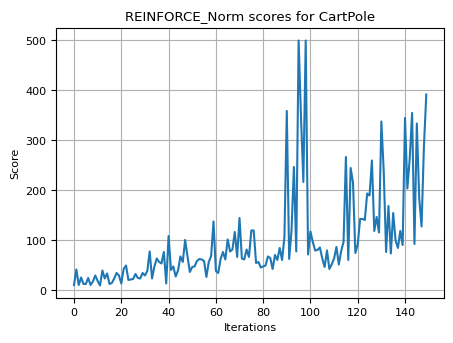

In [31]:
plt.plot(scores)
plt.title('REINFORCE_Norm scores for CartPole')
plt.ylabel('Score')
plt.xlabel('Iterations')
plt.grid()
plt.show()

**Normalize 사용으로 변동성 감소**  
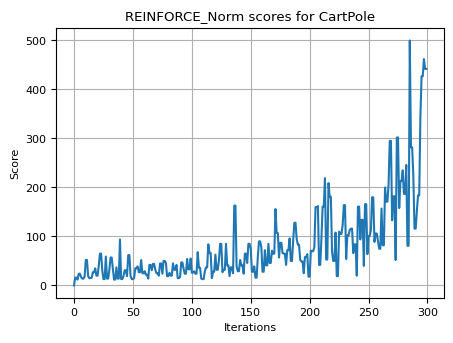

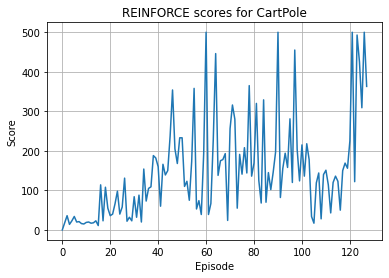



In [17]:
#net.save(path+"models/DRL/cartpole_by_REINFORCE_Norm.keras")
#net = keras.models.load_model(path+"models/DRL/cartpole_by_REINFORCE_Norm.keras")

## Evaluation

In [18]:
%%capture
!pip install pyvirtualdisplay
!sudo apt-get update
!sudo apt-get install python-opengl
!sudo apt-get install -f
!sudo apt-get upgrade --fix-missing
!sudo apt-get install xvfb

In [19]:
from pyvirtualdisplay import Display
virtual_display = Display(visible=0, size=(400, 300))
virtual_display.start()

In [20]:
from render import  show_video, wrap_env, render_as_image

In [21]:
eval_env = gym.make("CartPole-v1", render_mode='rgb_array')

video_prefix = "pt_reinforce_norm"
env_v = wrap_env(eval_env, path=path, name_prefix=video_prefix)

/usr/local/lib/python3.11/dist-packages/gymnasium/wrappers/rendering.py:296: UserWarning: WARN: Overwriting existing videos at /content/gdrive/MyDrive/Colab Notebooks/video folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [22]:
net_test = PolicyNetwork(state_size=s_dim, action_size=a_dim)
agent_test = ReinforceAgent(net_test)
agent_test.load_model(model_path)

모델을 /content/gdrive/MyDrive/Colab Notebooks/models/DRL/reinforce_cartpole_norm.pth에서 불러왔습니다.


시연 종료! 최종 점수: 52.0


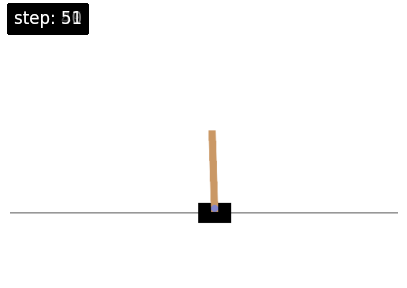

In [23]:
# 시연 시작
state, info = env_v.reset()
step_cnt = 0
total_reward = 0

while True:
    render_as_image(env_v, step=step_cnt)
    # 평가 시에는 학습된 정책에서 가장 확률이 높은 행동을 선택
    with torch.no_grad():
        state_tensor = torch.FloatTensor(state).unsqueeze(0)
        prob = agent_test.model(state_tensor)
        action = torch.argmax(prob).item()

    next_state, reward, terminated, truncated, info = env_v.step(action)
    done = terminated or truncated
    state = next_state
    total_reward += reward

    if done or step_cnt > 50 :
        print(f"시연 종료! 최종 점수: {total_reward}")
        break
    step_cnt += 1
env_v.close()

In [24]:
show_video(path=path, name_prefix=video_prefix)

/content/gdrive/MyDrive/Colab Notebooks/video/pt_reinforce_norm-episode-0.mp4


In [25]:
show_video(path=path,name_prefix='REINFORCE_Norm')

/content/gdrive/MyDrive/Colab Notebooks/video/REINFORCE_Norm-episode-0.mp4


# 실습 과제  
## 결과를 더 개선 해 보자   
## 1) update_every = 1 로 수정하고,
## 2) episode당 학습 횟수를 늘리면 어떠게 될까?
## 3) Return Normalization의 효과를 확인해 보자  

